## Setup

### Import Libraries

In [282]:
import torch
import torch.nn as nn
import torch.optim as optim

import copy

from sklearn.datasets import make_moons
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

### Utility Functions

In [416]:

def do_linear_regression_interactive(model, X, y_obs, optimizer, nepochs=50):
    

    # store initial model state to reset before training
    initial_state = copy.deepcopy(model.state_dict())

    def train_and_plot(epoch_to_show):
        # reset model to initial state
        model.load_state_dict(copy.deepcopy(initial_state))

        losses = []
        # train up to the selected epoch
        for epoch in range(epoch_to_show + 1):
            optimizer.zero_grad()
            y_pred = model(X)
            loss = (y_pred - y_obs).square().mean()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        # plot the data and model at this step
        with torch.no_grad():
            y_pred = model(X)
            loss = (y_pred - y_obs).square().mean()

        fig, axes = plt.subplots(ncols = 2, figsize = (10, 5))
        axes[0].set_title(f"Data and Model\nEpoch={epoch_to_show}, loss={loss:.4f}")
        axes[0].plot(X, y_obs, "o", color="black")
        axes[0].plot(X, model.weight.item()*X, color="r", label="Model")
        axes[0].set_xlabel('X')
        axes[0].set_ylabel('y')
        axes[0].legend()
        
        axes[1].set_title(f'Loss Throughout Training')
        axes[1].plot(np.arange(epoch_to_show+1), losses)
        axes[1].set_ylabel('Loss')
        axes[1].set_xlabel('Epoch Nr.')

    # create slider with steps of 1
    epoch_slider = widgets.IntSlider(min=0, max=nepochs, step=1, value=0, description='Epoch:')
    widgets.interact(train_and_plot, epoch_to_show=epoch_slider)

class utils:
    do_linear_regression_interactive = do_linear_regression_interactive


## Section 1: How to Build a Neural Network Model

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | Creates a single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `nn.Sigmoid()` | Creates a rectified linear unit activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.Sigmoid(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in that order.|

**Example**: Create a model with 2 input features and 16 output features.

In [5]:
nn.Linear(2, 16)

Linear(in_features=2, out_features=16, bias=True)

**Exercise**: Create the model illustrated below, which has 4 input features and 1 output features.

<img src="img/4x1_nn.jpg" width="300">


In [6]:
nn.Linear(4,1)

Linear(in_features=4, out_features=1, bias=True)

**Exercise**: Create the model illustrated below, which has 8 input features and 2 output features and assign it to a variable called `model`. Print the `model` variable.

<img src="img/8x2_nn.jpg" width="300">

In [7]:
model = nn.Linear(8,2)
print(model)

Linear(in_features=8, out_features=2, bias=True)


**Exercise**: In the cell below, a vector named `input` with 11 features (here, one feature is a single number) and a model with 11 input features and 1 output feature is created. 

<img src="img/11x1_nn.jpg" width="300">

Pass the variable `input` to the model.

The output from the model should look like this:
`tensor([ -2.8114,],
       grad_fn=<ViewBackward0>)`

In [ ]:
torch.manual_seed(2026)
model = nn.Linear(11,1)

input = torch.linspace(0,10,11)
input

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [ ]:
model(input)

tensor([-2.8114], grad_fn=<ViewBackward0>)

**Exercise**: Run the cell below to generate a new `input` vector that has `21` features. Try to pass this input to the same model. What does the error message say?

In [ ]:
torch.manual_seed(2025)
input = torch.linspace(0,10,21)
input

tensor([ 0.0000,  0.5000,  1.0000,  1.5000,  2.0000,  2.5000,  3.0000,  3.5000,
         4.0000,  4.5000,  5.0000,  5.5000,  6.0000,  6.5000,  7.0000,  7.5000,
         8.0000,  8.5000,  9.0000,  9.5000, 10.0000])

In [34]:
model(input)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x21 and 11x1)

Presumably, you got the following error message: "RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x21 and 11x1)".

You got this error because the dimensions of the `input` vector (1x21) don't match the number of input features in the model (which is 11). The number of input features in the first layer of the model must always be the same as the number of features in the data.

This error message also reveals an important fact about passing inputs through neural network models: It's a matrix multiplication! And when you do matrix multiplication, the dimensions of the matrices (along which the multiplication is carried out) have to match. To fix the issue above, you can create a new model with `21` input features.

**Exercise**: Create a model with 21 input features and 1 output features and assign it to a variable called `model`. Then pass the same input to the model as in the previous exercise. Did it run through now?

**Note**: You will probably get a different output value this time. That's because the initial weights of the model are set randomly and we don't have the same number of weights as before.

In [ ]:
model = nn.Linear(21,1)
model(input)

tensor([-1.9535], grad_fn=<ViewBackward0>)

**Example**: Create the model illustrated below, which has a single hidden layer in addition to the input and output layers. The model should have 2 input features and 1 output feature and the hidden layer should have 4 nodes. Display the model.

<img src="img/2x4x1_nn.jpg" width="300">

In [ ]:
model = nn.Sequential(
    nn.Linear(2,4),
    nn.Linear(4,1)
)
model

Sequential(
  (0): Linear(in_features=11, out_features=32, bias=True)
  (1): Linear(in_features=32, out_features=1, bias=True)
)

**Exercise**: Create a model with a single hidden layer in addition to the input and output layers. The model should have 21 input features and 2 output features and the hidden layer should have 16 nodes. Display the model.

In [36]:
model = nn.Sequential(
    nn.Linear(21,16),
    nn.Linear(16,2)
)
model

Sequential(
  (0): Linear(in_features=21, out_features=16, bias=True)
  (1): Linear(in_features=16, out_features=2, bias=True)
)

**Exercise**: Create the model illustrated below, which has two hidden layers in addition to the input and output layers. The model should have 2 input features and 1 output feature and the hidden layers should both have 4 nodes. Display the model.

<img src="img/2x4x2x1_nn.jpg" width="400">

In [ ]:
model = nn.Sequential(
    nn.Linear(2,4),
    nn.Linear(4,2),
    nn.Linear(2,1)
)
model

Sequential(
  (0): Linear(in_features=21, out_features=16, bias=True)
  (1): Linear(in_features=16, out_features=2, bias=True)
)

## Section 2: Optimize Model Parameters

After we have created a model, passed input to the model to get a prediction, and calculated the loss - the deviation between the prediction and the true value - the next step is to optimize the parameters of the model based on that loss. We already did this in the previous session: we implemented the optimization method called *gradient descent* to update parameter values ourselves. However, PyTorch has a package called `optim` providing optimizer objects that take care of the optimization for us. Just as a reminder, the update rule in gradient descent for a parameter $w_i$ is expressed mathematically as follows:

$$
w_{i, t+1} = w_{i,t} - \eta \times \nabla L(w_{i,t})
$$

where $t$ is the current time step (epoch) in the training, $L$ is loss function to be minimized, and $\eta$ is the learning rate.

| Code | Description |
| --- | --- |
| `optim.SGD(model.parameters())` | Creates a gradient descent optimizer. |
| `optim.SGD(model.parameters(), lr=0.01)` | Creates a gradient descent optimizer with a learning rate `lr` of 0.01 (the default value is 0.001). |
| `optimizer.zero_grad()` | Resets the gradients before the next iteration in the optimization. |
| `loss.backward()`| Performs backward propagation and calculates the gradients through the graph leaves (network). |
| `optimizer.step()` | Update the parameters of the network. |
| `for epoch in range(10):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(epoch)` | Print every number `epoch` between 0 and 10 (not including 5)|

**Example**: Create the model illustrated below with a two input features and one output feature. (For simplicity, the bias was left out of the illustrations in the previous section.) Then, print the model's weights and biases.

In [50]:
torch.manual_seed(2026)
model = nn.Linear(2,1)
model

Linear(in_features=2, out_features=1, bias=True)

In [54]:
print(f'Weights: {model.weight}')
print(f'biases: {model.bias}')

Weights: Parameter containing:
tensor([[-0.4915, -0.3508]], requires_grad=True)
biases: Parameter containing:
tensor([0.3267], requires_grad=True)


**Exercise**: Create a model illustrated below with a one input feature and two output features. Then, print the model's weights and biases.

In [56]:
torch.manual_seed(2026)
model = nn.Linear(1,2)

print(f'Weights: {model.weight}')
print(f'biases: {model.bias}')

Weights: Parameter containing:
tensor([[-0.6950],
        [-0.4962]], requires_grad=True)
biases: Parameter containing:
tensor([ 0.4620, -0.8715], requires_grad=True)


**Exercise**: Print the weights and biases of the model created below.

In [42]:
torch.manual_seed(2026)
model = nn.Linear(2,4)
model

Linear(in_features=2, out_features=4, bias=True)

In [57]:
print(f'Weights: {model.weight}')
print(f'biases: {model.bias}')

Weights: Parameter containing:
tensor([[-0.6950],
        [-0.4962]], requires_grad=True)
biases: Parameter containing:
tensor([ 0.4620, -0.8715], requires_grad=True)


All the parameters of the model can also be accessed together, instead of accessing the weights and biases separately, by using `model.parameters()`. Run the cell below to access and print for the same model.

In [44]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[-0.4915, -0.3508],
        [ 0.3267, -0.6162],
        [-0.6807, -0.0077],
        [ 0.3651, -0.7058]], requires_grad=True)
Parameter containing:
tensor([ 0.2803, -0.6414,  0.4425, -0.4307], requires_grad=True)


**Example**: Create a gradient descent optimizer for the model defined in the cell above. Remember to pass the parameters to be optimized - the model's parameters - to the optimizer. Assign it to a variable named `optimizer`.

In [58]:
optimizer = optim.SGD(model.parameters())
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

**Exercise**: Create a gradient descent optimizer with a learning rate of `0.1` for the same model. Remember to pass the parameters to be optimized - the model's parameters - to the optimizer. Assign it to a variable named `optimizer`.

In [59]:
optimizer = optim.SGD(model.parameters(), lr=0.1)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

Below, we create a linear model for the following equation (the same one you worked with in session 02): 

$ y = a \times x $ 

The weight paramter of the model corresponds to `a` in this equation. We set the initial weight (value of the parameter `a`) to `3` - that's our initial guess for the parameter before we start optimizing.

In [237]:
# create model
model = nn.Linear(1,1, bias=False)
# set initial weigh of model equal to 3.0
model.weight.data = torch.tensor([[3.0]])

# create optimizer for model 
optimizer = optim.SGD(model.parameters(), lr=0.1)

print(f'Initial parameter value of model: {model.weight.data}')

Initial parameter value of model: tensor([[3.]])


Run the cell below to predict a value `y_pred` for the input `x` and the initial parameter guess `a=3` and calculate the loss of this first prediction.

In [238]:
# define observed y-value
y_obs = torch.tensor([10], dtype=torch.float)

# define input
x = torch.tensor([2.0])

# make a prediction
y_pred = model(x)

# calculate loss
loss = nn.MSELoss()(y_pred, y_obs)
print(f'y_obs: {y_obs.item()}, y_pred: {y_pred.item():.1f}, loss: {loss.item():.3f}')

y_obs: 10.0, y_pred: 6.0, loss: 16.000


**Example**: Do backpropagation on the loss computed in the cell above and update the parameters of the model with the optimizer. Has the parameter (weight) of the model changed from the initial value we set above?

In [239]:
loss.backward()
optimizer.step()
print(f'New parameter value: {model.weight.data}')

New parameter value: tensor([[4.6000]])


`loss.backward()` automatically computes the gradients of all parameters (it's just one in this case) in the model and these gradients are used to update the parameter values for the next iteration when `optimizer.step()` is called.

Now that the parameter value has been updated, we make a new prediction `y_pred` and calculate the loss for that new prediction. Run the cell below.

In [ ]:
# zero out gradients before next iteration
optimizer.zero_grad()

# make a prediction
y_pred = model(x)

# calculate loss
loss = nn.MSELoss()(y_pred, y_obs)
print(f'y_obs: {y_obs.item()}, y_pred: {y_pred.item():.2f}, loss: {loss.item():.3f}')

y_obs: 10.0, y_pred: 9.20, loss: 0.640


**Exercise**: Do backpropagation on the loss computed in the cell above and update the parameters of the model with the optimizer. Print the new model weight. Has the parameter (weight) of the model changed from the previous value (the value in the example)?

In [241]:
loss.backward()
optimizer.step()
print(f'New value: {model.weight}')

New value: Parameter containing:
tensor([[4.9200]], requires_grad=True)


Let's make a last prediction with the updated parameter value. Run the cell below to make a new prediction with the updated model. Is the prediction `y_pred` now close to the observed value `y_obs`?

In [243]:
# zero out gradients before next iteration
optimizer.zero_grad()

# make a prediction
y_pred = model(x)

# calculate loss
loss = nn.MSELoss()(y_pred, y_obs)
print(f'y_obs: {y_obs.item()}, y_pred: {y_pred.item():.2f}, loss: {loss.item():.3f}')

y_obs: 10.0, y_pred: 9.84, loss: 0.026


**Demo**: You may have noticed the line `optimizer.zero_grad()` in two of the cells above. This zeros out the gradients before the next iteration. If we don't do this, the gradients will accumulate over the iterations. In the demo below, you can see an example of an iteration with and without zeroing out the gradients (with no parameter updates in this case). Observe what happens to the gradient when it's not zeroed out in each iteration.

In [260]:
model = nn.Linear(1,1, bias=False)
model.weight.data = torch.tensor([[3.0]])
optimizer = optim.SGD(model.parameters(), lr=0.1)

print('\nZeroing out gradients:')
for epoch in range(4):
    # zero out gradients
    optimizer.zero_grad()

    y_pred = model(x)
    loss = nn.MSELoss()(y_pred, y_obs)
    loss.backward()

    print(f'epoch: {epoch}, gradient: {model.weight.grad.item()}')

print('\nWithout zeroing out gradients:')

for epoch in range(4):
    y_pred = model(x)
    loss = nn.MSELoss()(y_pred, y_obs)
    loss.backward()

    print(f'epoch: {epoch}, gradient: {model.weight.grad.item()}')


Zeroing out gradients:
epoch: 0, gradient: -16.0
epoch: 1, gradient: -16.0
epoch: 2, gradient: -16.0
epoch: 3, gradient: -16.0

Without zeroing out gradients:
epoch: 0, gradient: -32.0
epoch: 1, gradient: -48.0
epoch: 2, gradient: -64.0
epoch: 3, gradient: -80.0


As in the previous session, we can put this optimization (iterative improvement) in a loop so we don't have to write the code and run the cells over and over.

**Exercise**: Put the following code in a loop of 5 epochs.

In [271]:
# create model
model = nn.Linear(1,1, bias=False)
model.weight.data = torch.tensor([[3.0]])

# create optimizer for model 
optimizer = optim.SGD(model.parameters(), lr=0.1)

'''put the code below in a for loop with 5 epochs'''

# reset the gradients
optimizer.zero_grad()

# pass the input to the model
y_pred = model(x)

# calculate the loss
loss = nn.MSELoss()(y_pred, y_obs)

# perform backward propagation to calculate the gradients
loss.backward()

print(f'a: {model.weight.item():.2f}, y_obs: {y_obs.item()}, y_pred: {y_pred.item():.2f}, loss: {loss.item():.3f}')

# update the parameters
optimizer.step()

a: 3.00, y_obs: 10.0, y_pred: 6.00, loss: 16.000


In [ ]:
# create model
model = nn.Linear(1,1, bias=False)
model.weight.data = torch.tensor([[3.0]])

# create optimizer for model 
optimizer = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(5):
    # reset the gradients
    optimizer.zero_grad()

    # pass the input to the model
    y_pred = model(x)

    # calculate the loss
    loss = nn.MSELoss()(y_pred, y_obs)

    # perform backward propagation to calculate the gradients
    loss.backward()

    print(f'epoch: {epoch}, a: {model.weight.item():.2f}, y_obs: {y_obs.item()}, y_pred: {y_pred.item():.2f}, loss: {loss.item():.3f}')

    # update the parameters
    optimizer.step()

epoch: 0, a: 3.00, y_obs: 10.0, y_pred: 6.00, loss: 16.000
epoch: 1, a: 4.60, y_obs: 10.0, y_pred: 9.20, loss: 0.640
epoch: 2, a: 4.92, y_obs: 10.0, y_pred: 9.84, loss: 0.026
epoch: 3, a: 4.98, y_obs: 10.0, y_pred: 9.97, loss: 0.001
epoch: 4, a: 5.00, y_obs: 10.0, y_pred: 9.99, loss: 0.000


## Section 3: Learning Rate and Optimizer Choice Affect Training Speed and Whether the Model Converges


| Code | Description |
| --- | --- |
| `torch.optim.SGD(model.parameters())` | Creates a gradient descent (GD) optimizer. |
| `torch.optim.SGD(model.parameters(), lr=0.01)` | Creates a gradient descent (GD) optimizer with a learning rate `lr` of 0.01 (the default value is 0.001). |
| `torch.optim.Adagrad(model.parameters())` | Creates an adaptive gradient optimizer.|
| `torch.optim.RMSprop(model.parameters())` | Creates an root mean square (RMS) propagation optimizer.|
| `torch.optim.Adam(model.parameters())` | Creates an adaptive moment optimizer .|
| `utils.do_linear_regression(model, X, y, optimizer)` | Create interactive plot where a linear model is trained to fit data through linear regression. |

Run cell below to generate data.

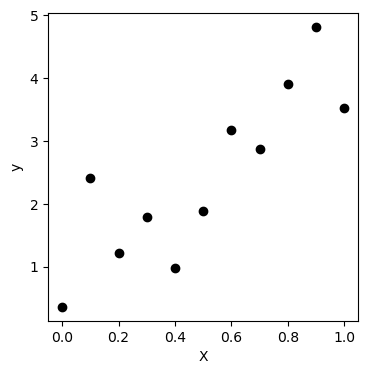

In [404]:
torch.manual_seed(2026)
X = torch.linspace(0,1,11).unsqueeze(1)

y_obs = 5*X + torch.randn_like(X)

plt.figure(figsize=(4,4))
plt.plot(X, y_obs, 'o', color='black')
plt.xlabel("X")
plt.ylabel("y");

**Demo**: In the previous section, we only used a single data point - a single observation `y_obs = 10`. Usually, we has more samples when we want to fit a model to data. After running the cell below, you'll see an interactive plot showing the model fit throughout the training of the same linear model as before. When you drag the slider, you train the model. One iteration in the training is one epoch.

In [417]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=50), Output()), _dom_classes=('widget-inter…

**Example**: For the model created below, create a gradient descent optimizer with learning rate `lr = 0.01`. Then, run the interactive plot and use the slider to train the model. Does the model fit the data well after 30 epochs? Compare to the demo above if you're not sure.

In [418]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

In [419]:
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

In [420]:
utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

# the model does not align with the data after 30 epochs

interactive(children=(IntSlider(value=0, description='Epoch:', max=50), Output()), _dom_classes=('widget-inter…

**Exercise**: For the model created below, create a gradient descent optimizer with learning rate `lr = 1`. Then, run the cell with the interactive plot below and use the slider to train the model. What happens to the loss throughout training? How many epochs does it take for the model to fit the data well now? Compare to the demo above if you're not sure.

In [421]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

In [422]:
optimizer = torch.optim.SGD(model.parameters(), lr = 1)

In [ ]:
utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=50), Output()), _dom_classes=('widget-inter…

As you may have observed in the last exercise and as the name suggests, a higher learning rate means that the model learns faster. What happens is that the parameters are updated in larger steps for each iteration. But is a higher learning rate always better?

**Exercise**: For the model created below, create a gradient descent optimizer with learning rate `lr = 3`. Then, run the cell with the interactive plot below and use the slider to train the model. What happens to the loss throughout training? Is the model able to fit the data in the end?

In [426]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

In [427]:
optimizer = torch.optim.SGD(model.parameters(), lr = 3)

In [428]:
utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=50), Output()), _dom_classes=('widget-inter…

`SGD` is just one of many optimization algorithms that PyTorch provides. Let's try out some of the others. The data and model above are too simple to showcase the differences between the various algorithms.

In [ ]:
# Features with very different scales
X = torch.randn(100, 2)
X[:, 0] *= 100
X[:, 1] *= 0.01

# A deeper network with more parameters
model = nn.Sequential(
    nn.Linear(10, 32),
    nn.Linear(32, 16),
    nn.Linear(16, 1)
)


**Exercise**: For the model created below, create an `Adagrad` optimizer with learning rate `lr = 1`. Then, run the cell with the interactive plot below and use the slider to train the model. Does the model fit the data well after 50 epochs? 

In [429]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

In [430]:
optimizer = torch.optim.Adagrad(model.parameters(), lr = 1)

In [ ]:
utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=50), Output()), _dom_classes=('widget-inter…

`SGD` is just one of many optimization algorithms that PyTorch provides. Let's try out some of the others.

**Exercise**: For the model created below, create an `RMSprop` optimizer with learning rate `lr = 1`. Then, run the cell with the interactive plot below and use the slider to train the model. Does the model fit the data well after 30 epochs? 

In [432]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

In [433]:
optimizer = torch.optim.RMSprop(model.parameters(), lr = 0.1)

In [434]:
utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=50), Output()), _dom_classes=('widget-inter…

`SGD` is just one of many optimization algorithms that PyTorch provides. Let's try out some of the others.

**Exercise**: For the model created below, create an `Adam` optimizer with learning rate `lr = 1`. Then, run the cell with the interactive plot below and use the slider to train the model. Does the model fit the data well after 30 epochs? 

In [435]:
torch.manual_seed(2025)
model = nn.Linear(1,1, bias=False)

In [436]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.1)

In [437]:
utils.do_linear_regression_interactive(model, X, y_obs, optimizer = optimizer)

interactive(children=(IntSlider(value=0, description='Epoch:', max=50), Output()), _dom_classes=('widget-inter…

## Section 4: Effect of Initialization